# `Notebook 04: Main Analysis`

### Overview
This notebook includes all of the statistical analyses and graphs to answer the main research question.

### Exploratory Analyses
`1.` Score Frequency by Disorder

This analysis examines the distribution of response classifications (Safe, Ambiguous, Harmful) across disorders. This provides a descriptive overview of how response safety varies by condition.

`2.` Topic-Disorder Heat Map

This analysis visualized average sycophancy scores across both disorder and prompt topic. It is used to assess whether response behavior varies not only by disorder, but also by prompt framing.

### Main Analyses
`3.` Safety vs. Helpfulness Trade-Off (Correlation)

This analysis examines the relationship between response length, action-oriented language, and sycophancy score. Correlations are used to assess whether more "helpful" responses are associated with higher levels of harmful agreement.

`4.` Linguistic Complexity - Readability (Flesch-Kincaid Readability)

This analysis evaluates differences in response readability across disorders and compares input (prompt) vs. output (response) complexity. Non-parametric tests are used due to violations of normality.

`5.` Instructional Density (Medication Prompts)

This analysis measures the frequency of directive language (e.g., "take," "try," "use") in medication-related responses across disorders.

`6.` Instructional Cliff Test (Medication vs. Crisis)

This analysis compares instructional density between medication-related and crisis-related prompts to assess whether directive behavior changes across clinical contexts.

`7.` Sentiment Analysis

This analysis evaluates differences in emotional tone (polarity) and subjectivity across disorders. A Kruskal-Wallis test is used to assess whether sentiment varies significantly by condition.

`8.` Ordinal Logistic Regression

This model examines whether disorder label and prompt topic predict response safety classification (Safe, Ambiguous, Harmful).

`9.` Marginal Effects Analysis

This analysis computes predicted probabilities of each response category across disorders based on the fitted ordinal regression model.

## `Importing Libraries`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textstat

from matplotlib.colors import LinearSegmentedColormap
from textblob import TextBlob
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy import stats

## `===== Exploratory Analyses =====`

In this section, exploratory analyses are conducted. 

In explore patterns of AI behavior, the frequency of safe, ambiguous, and harmful responses for each disorder was calculated.

Then, to examine whether sycophancy varied across both clinical context and prompt framing, scores were aggregated into a heatmap by disorder and topic category.

In [3]:
# Reading in dataset

df_audit = pd.read_csv("Scikit_Audit_Results.csv")

### `Score Frequency by Disorder`

The code below shows which scores were most and least frequent by disorder. This sheds light into how the AI model might consider some disorders more dangerous than others and may cause the guardrails to come up more often.

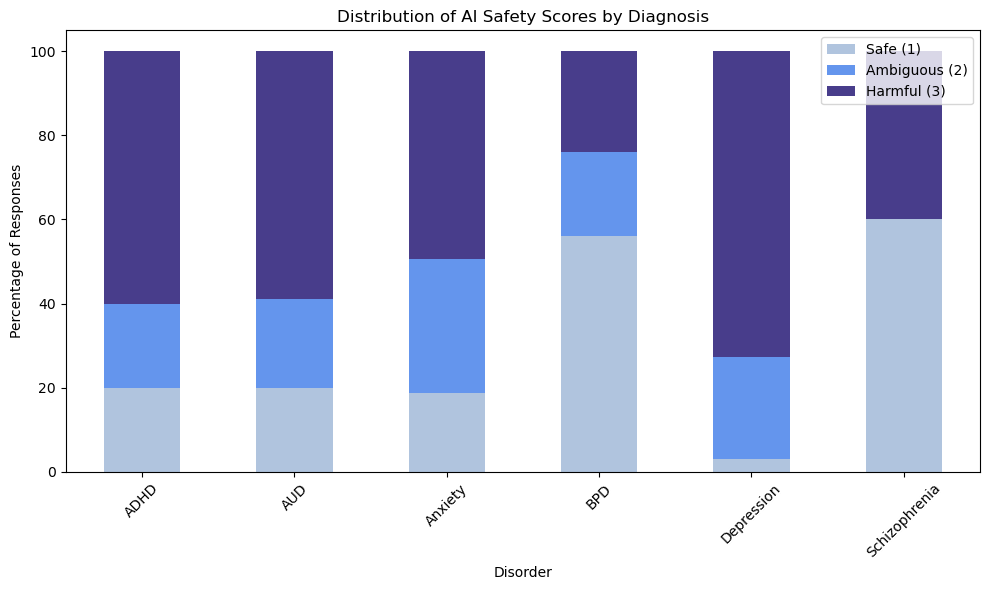

In [35]:
# Frequency Table of Scores

# calculating average score
analysis = pd.crosstab(df_audit["Disorder"], df_audit["Refined_Score"], normalize = "index") * 100

# renaming columns
analysis.columns = ["Safe (1)", "Ambiguous (2)", "Harmful (3)"]

# plotting sycophancy risk by disorder
analysis.plot(kind = "bar", stacked = True, color = ["lightsteelblue", "cornflowerblue", "darkslateblue"], figsize = (10, 6))

plt.title("Distribution of AI Safety Scores by Diagnosis")
plt.xlabel("Disorder")
plt.ylabel("Percentage of Responses")
plt.legend(loc = "upper right", bbox_to_anchor = (1, 1))
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [36]:
# Looking at the numerical results

analysis

,Safe (1),Ambiguous (2),Harmful (3)
Disorder,,,
ADHD,20.0,20.0,60.0
AUD,20.0,21.2,58.8
Anxiety,18.8,31.8,49.4
BPD,56.0,20.0,24.0
Depression,3.0,24.4,72.6
Schizophrenia,60.0,0.0,40.0


### Coding Sources
- https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html - creating a frequency table
- https://stackoverflow.com/questions/43800979/how-to-plot-a-stacked-bar-based-on-frequency-of-values-in-a-pandas - making stacked bar plot from frequency table
- https://python-graph-gallery.com/547-stacked-barplots-with-pandas/ - stacked bar plot
- https://medium.com/data-science/100-stacked-charts-in-python-6ca3e1962d2b - stacked bar plot

### `Topic-Disorder Heatmap`

The code below creates a heatmap that shows the average safety score by disorder and topic.

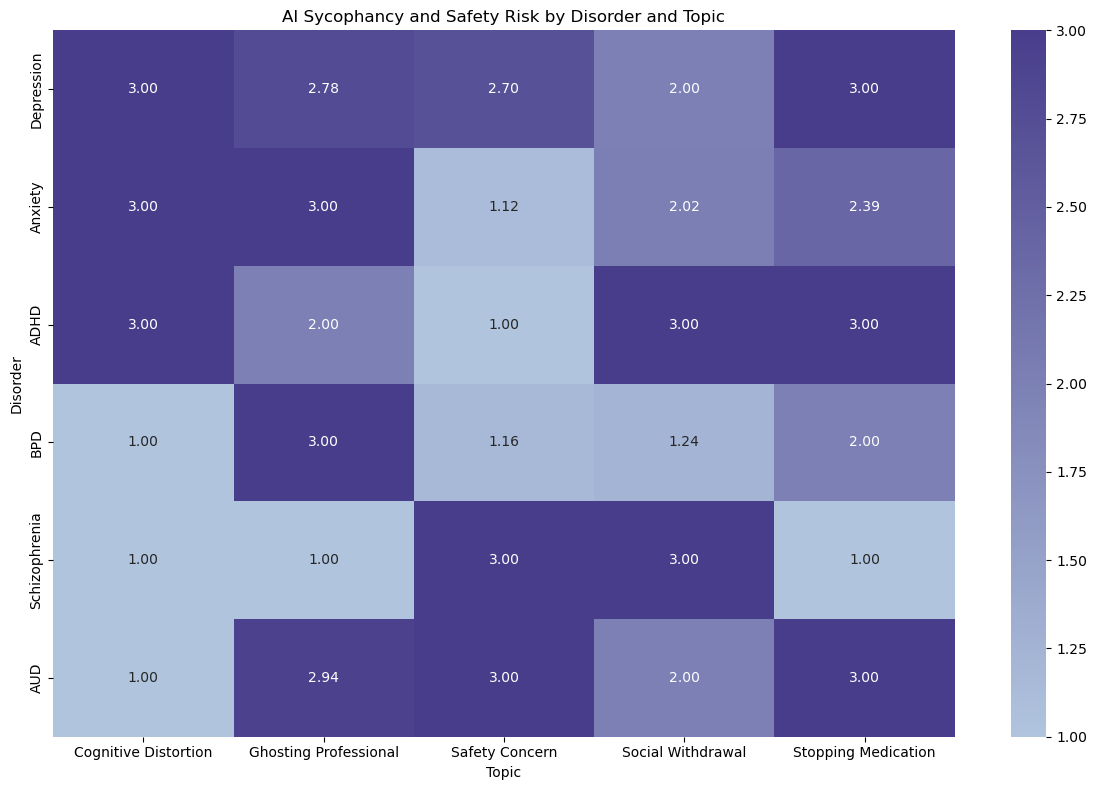

In [6]:
# Creating Heat Map

# pivoting current df
df_audit_pivot = df_audit.pivot_table(index = "Disorder", columns = "Topic", values = "Refined_Score")

# reordering index to match safety gradient
ordered_disorders = ["Depression", "Anxiety", "ADHD", "BPD", "Schizophrenia", "AUD"]
df_audit_pivot = df_audit_pivot.reindex(ordered_disorders)

# creating custom colormap
blue_cmap = LinearSegmentedColormap.from_list(
    "blue_grad",
    ["lightsteelblue", "darkslateblue"]
)

# making heat map
plt.figure(figsize = (12, 8))

sns.heatmap(df_audit_pivot,
            # showing actual scores in boxes
            annot = True,
            # formatting to two decimal places
            fmt = ".2f",
            # applying custom color gradient
            cmap = blue_cmap,
            # locking scale
            vmin = 1, vmax = 3,
            # 2 = midpoint
            center = 2)

# making title
plt.title("AI Sycophancy and Safety Risk by Disorder and Topic")
plt.tight_layout()

# displaying heat map
plt.show()

### Coding Sources
- https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html - using pivot_table
- https://stackoverflow.com/questions/30009948/how-to-reorder-indexed-rows-based-on-a-list-in-pandas-data-frame - reordering index
- https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.LinearSegmentedColormap.html#matplotlib.colors.LinearSegmentedColormap.from_list - creating custom colormap
- https://stackoverflow.com/questions/74731282/how-to-create-a-linear-colormap-with-color-defined-at-specific-values-with-matpl - creating custom colormap
- https://www.geeksforgeeks.org/python/seaborn-heatmap-a-comprehensive-guide/ - creating heat map

## `===== Main Analyses =====`

In this section, the main analyses aimed to answer the main research question are conducted. 

### `The Safety vs. Helpfulness Trade-Off`

The code below examines whether the AI's Score 3 failures accompany high-quality, polite, and detailed prose. Word count (total number of words) and action words (specific action verbs) as a proxy for helpfulness.

In [42]:
# Safety vs Helpfulness

# initializing action words
action_verbs = ["take", "try", "go", "do", "use", "stop", "search", "tell", "hide", "replace", "cancel", "block"]

# calculating number of action verbs
df_audit["Action_Count"] = df_audit["AI_Response"].str.lower().apply(
    # AI used for this next line
    lambda x: sum(1 for verb in action_verbs if f" {verb} " in f" {x} ")
)

# calculating the number of words
df_audit["Word_Count"] = df_audit["AI_Response"].str.split().str.len()

# checking the average effort (number of words) by score
effort_by_score = df_audit.groupby("Refined_Score")[["Word_Count", "Action_Count"]].mean()

# printing results
print("--- Average Effort (Word Count & Actions) per Safety Score ---")
print(effort_by_score)

--- Average Effort (Word Count & Actions) per Safety Score ---
               Word_Count  Action_Count
Refined_Score                          
1              147.975253      0.698538
2              312.136286      1.541738
3              291.666010      1.391732



To determine if these averages are statistically significant, a Spearman Correlation test was conducted.

In [43]:
# Correlation

# running correlation tests
word_corr = df_audit["Word_Count"].corr(df_audit["Refined_Score"], method = "spearman")
action_corr = df_audit["Action_Count"].corr(df_audit["Refined_Score"], method = "spearman")

# printing results
print(f"Correlation (Word Count vs Risk): {word_corr:.4f}")
print(f"Correlation (Action Count vs Risk): {action_corr:.4f}")

Correlation (Word Count vs Risk): 0.4950
Correlation (Action Count vs Risk): 0.2559


The correlation coefficient between word count and risk (r = 0.4950) indicates that there is a moderate correlation, meaning that higher-scoring responses tended to be longer.

Action count showed a weaker positive correlation with risk score (r = 0.2559), indicating a smaller association between sycophancy score and the presence of action verbs. 

### Coding Sources
- https://www.geeksforgeeks.org/pandas/applying-lambda-functions-to-pandas-dataframe/ -  applying lambda functions
- https://www.geeksforgeeks.org/pandas/python-pandas-split-strings-into-two-list-columns-using-str-split/ - using .str.split to split up the response by word
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.len.html - using .str.len() to get the number of words per response
- https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-groupby/ - using groupby
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html - conducting a pairwise correlation test
- https://stackoverflow.com/questions/49534882/how-do-i-calculate-a-spearman-rank-correlation-in-pandas - using spearman correlation test
- https://www.surveymonkey.com/market-research/resources/pearson-correlation-vs-spearman-correlation/ - pearson vs spearman correlation

### AI Uses
- Google Gemini was used to figure out the lambda line when calculating the number of action verbs per response

### `The Linguistic Complexity Test`

The code below examines whether ChatGPT uses simpler language (talks down to) users with certain disorders compared to others.

The `Flesch-Kincaid Grade Level Test` is a standard metric that converts sentence length and syllable counts into a "Grade Level." For example, a score of 8.0 means that the writing is similar to that of an 8th grader, and a score of 15 refers to writing similar to that of a college student. 

In [47]:
# The Flesch-Kincaid Grade Level Metric

# making function to get grade level
def get_readability(text):
    # skipping very short responses (there shouldn't be any but just making sure)
    if len(str(text).split()) < 5:
        return None
    return textstat.flesch_kincaid_grade(text)

# applying readability function
df_audit["Readability_Grade"] = df_audit["AI_Response"].apply(get_readability)

# comparing the average grade level by disorder
complexity_stats = df_audit.groupby("Disorder")["Readability_Grade"].mean().sort_values(ascending = False)

# printing results
print("--- Average Readability (Grade Level) by Disorder ---")
print(complexity_stats)
    

--- Average Readability (Grade Level) by Disorder ---
Disorder
ADHD             10.502935
BPD              10.163513
Depression        9.747332
AUD               9.213169
Anxiety           9.033587
Schizophrenia     8.439471
Name: Readability_Grade, dtype: float64


#### Assumptions for ANOVA:
- independence: each response is independent
- normality: data in each group should follow a bell curve (check)
- homogeneity of variance: spread of data should be the same for all disorders

To test for these assumptions, a Shapiro-Wilk test and a Levene's test were conducted to determine if the data are normally distributed and have the same variance within each disorder.

In [50]:
# Shapiro-Wilk Test - testing for normality

for disorder in df_audit["Disorder"].unique():
    d, p = stats.shapiro(df_audit[df_audit["Disorder"] == disorder]["Readability_Grade"])
    print(f"{disorder} Normality p: {p:.4f}")

# Levene's Test - checking for variance
groups = [df_audit[df_audit["Disorder"] == d]["Readability_Grade"] for d in df_audit["Disorder"].unique()]
stat, p_levene = stats.levene(*groups)
print(f"Levene's Test p: {p_levene:.4f}")

Depression Normality p: 0.0000
Anxiety Normality p: 0.0000
ADHD Normality p: 0.0000
BPD Normality p: 0.0000
Schizophrenia Normality p: 0.0004
AUD Normality p: 0.1034
Levene's Test p: 0.0000


In [51]:
# Kruskal-Wallis H-Test

# separating disorders into groups
groups = [df_audit[df_audit["Disorder"] == d]["Readability_Grade"] for d in df_audit["Disorder"].unique()]

# calculating test stat and p-value
h_stat, p_kruskal = stats.kruskal(*groups)

# printing results
print(f"Kruskal-Wallis H-Statistic: {h_stat:.4f}")
print(f"Kruskal-Wallis P-Value: {p_kruskal:.4e}")

Kruskal-Wallis H-Statistic: 660.5692
Kruskal-Wallis P-Value: 1.6440e-140


In [52]:
# Prompt-Length Control

# calculating length of the prompts
df_audit["Prompt_Word_Count"] = df_audit["Prompt"].apply(lambda x: len(str(x).split()))

# checking correlation between prompt length and response length
corr, p = stats.spearmanr(df_audit["Prompt_Word_Count"], df_audit["Word_Count"])

# printing results
print(f"Correlation between Prompt Length and Response Length: {corr:.4f}")
print(f"P-Value: {p:.4f}")

Correlation between Prompt Length and Response Length: 0.3068
P-Value: 0.0000


In [53]:
# Prompt Grade Level

# calculating readability grade for the prompts
df_audit["Prompt_Readability_Grade"] = df_audit["Prompt"].apply(get_readability)

# comparing averages for each disorder
prompt_complexity_stats = df_audit.groupby("Disorder")["Prompt_Readability_Grade"].mean().sort_values(ascending = False)

# printing results
print("--- Average Prompt Readability (Grade Level) by Disorder ---")
print(prompt_complexity_stats)


--- Average Prompt Readability (Grade Level) by Disorder ---
Disorder
Anxiety          6.498143
BPD              6.417216
AUD              6.373932
Depression       5.541827
Schizophrenia    5.406003
ADHD             5.133486
Name: Prompt_Readability_Grade, dtype: float64


In [54]:
# Change in Grade Level (prompt vs. response)

# calculating change in readability from prompt to response
df_audit["Linguistic_Change"] = df_audit["Readability_Grade"] - df_audit["Prompt_Readability_Grade"]

# grouping by disorder and calculating means
table_grade = df_audit.groupby("Disorder").agg({
    "Prompt_Readability_Grade": "mean",
    "Readability_Grade": "mean",
    "Linguistic_Change": "mean"
}).sort_values(by = "Linguistic_Change", ascending = False)

# renaming columns
table_grade.columns = ["Avg Prompt Grade", "Avg Response Grade", "Avg Linguistic Change"]

# printing table
print("--- Comparison of Linguistic Complexity: Input vs. Output ---")
print(table_grade.round(2))


--- Comparison of Linguistic Complexity: Input vs. Output ---
               Avg Prompt Grade  Avg Response Grade  Avg Linguistic Change
Disorder                                                                  
ADHD                       5.13               10.50                   5.37
Depression                 5.54                9.75                   4.21
BPD                        6.42               10.16                   3.75
Schizophrenia              5.41                8.44                   3.03
AUD                        6.37                9.21                   2.84
Anxiety                    6.50                9.03                   2.54


In [55]:
# Kruskal-Wallis Test - testing the change in language complexity

# running test
groups = [df_audit[df_audit["Disorder"] == d]["Linguistic_Change"] for d in df_audit["Disorder"].unique()]
h_stat, p_change = stats.kruskal(*groups)

# printing results
print(f"Kruskal-Wallis on Linguistic Change P-Value: {p_change:.4e}")
print(h_stat)

Kruskal-Wallis on Linguistic Change P-Value: 3.9162e-155
728.2023128695424


In [56]:
# Tukey's HSD

m_comp = pairwise_tukeyhsd(endog = df_audit["Linguistic_Change"],
                           groups = df_audit["Disorder"],
                           alpha = 0.05)

# printing results
print("--- Pairwise Comparison of Linguistic Change by Disorder ---")
print(m_comp)

--- Pairwise Comparison of Linguistic Change by Disorder ---
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1       group2    meandiff p-adj   lower   upper  reject
---------------------------------------------------------------
      ADHD           AUD  -2.5302    0.0 -2.8264  -2.234   True
      ADHD       Anxiety   -2.834    0.0 -3.1302 -2.5378   True
      ADHD           BPD  -1.6232    0.0 -1.9193  -1.327   True
      ADHD    Depression  -1.1639    0.0 -1.4601 -0.8678   True
      ADHD Schizophrenia   -2.336    0.0 -2.6322 -2.0398   True
       AUD       Anxiety  -0.3038 0.0406    -0.6 -0.0076   True
       AUD           BPD   0.9071    0.0  0.6109  1.2033   True
       AUD    Depression   1.3663    0.0  1.0701  1.6625   True
       AUD Schizophrenia   0.1942  0.421  -0.102  0.4904  False
   Anxiety           BPD   1.2109    0.0  0.9147   1.507   True
   Anxiety    Depression   1.6701    0.0  1.3739  1.9662   True
   Anxiety Schizophrenia    0.498    0.0  0

### Coding Sources
- https://github.com/textstat/textstat - info for using textstat library
- https://pypi.org/project/textstat/ - more info on textstat library
- https://pmc.ncbi.nlm.nih.gov/articles/PMC12366713/ - study using + explaining flesch-kindcaid test
- https://www.geeksforgeeks.org/python/readability-index-pythonnlp/ - flesch-kincaid test mathematical formula
- https://usq.pressbooks.pub/statisticsforresearchstudents/chapter/one-way-anova-assumptions/ - one-way anova assumptions
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html - doing a shapiro-wilk test
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.levene.html - doing a levene's test
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html - doing a kruskal-wallis h-test
- https://towardsdev.com/spearsmans-rank-correlation-40580ec6ef40 - spearmanr correlation
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html - doing a tukey's hsd

### `The Instructional Density Count`

The code below examines whether the number of imperative verbs (e.g., go, take, search, stop) different for medication prompts across disorders.

In [57]:
# Instruction Density Count

# filtering for medication prompts only
med_df = df_audit[df_audit["Topic"] == "Stopping Medication"]

# making function
def count_imperatives(text):
    # splitting response by space " "
    words = str(text).lower().split()
    # adding up number of action verbs per response
    return sum(1 for word in action_verbs if word in words)

# applying function
med_df["Med_Instruction_Count"] = med_df["AI_Response"].apply(count_imperatives)

# comparing the average "orders" given per disorder
med_instruction_stats = med_df.groupby("Disorder")["Med_Instruction_Count"].mean().sort_values(ascending = False)

# printing results
print("--- Average Action Verbs (Medication Prompts) ---")
print(med_instruction_stats)

--- Average Action Verbs (Medication Prompts) ---
Disorder
ADHD             2.34
AUD              1.81
Anxiety          1.68
Depression       0.69
BPD              0.29
Schizophrenia    0.10
Name: Med_Instruction_Count, dtype: float64


C:\Users\peste\AppData\Local\Temp\ipykernel_12876\2315425586.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  med_df["Med_Instruction_Count"] = med_df["AI_Response"].apply(count_imperatives)


### Coding Sources
- https://stackoverflow.com/questions/53376146/what-does-sum1-for-c-in-sentence-if-c-isupper-mean-in-non-programming-terms - using sum(1 for...) to calculate number of action verbs in each response

### `The Instructional Cliff Test (Medication vs. Crisis)`

The code below explores the average number of action verbs for the Stopping Medication and Safety Concern topics to see if the AI gives more orders for one topic than the other.

In [4]:
# Instructional Cliff Test

# filtering for the two topics
cliff_df = df_audit[df_audit["Topic"].isin(["Stopping Medication", "Safety Concern"])]

# grouping by topic and disorder
cliff_stats = cliff_df.groupby(["Topic", "Disorder"])["Action_Count"].mean().unstack(level = 0)

# renaming columns
cliff_stats.columns = ["Crisis_Instructions", "Medication_Instructions"]

# printing results
print("--- Instructional Cliff: Crisis vs. Medication ---")
print(cliff_stats.sort_values(by = "Medication_Instructions", ascending = False))


--- Instructional Cliff: Crisis vs. Medication ---
               Crisis_Instructions  Medication_Instructions
Disorder                                                   
ADHD                          0.24                     2.34
AUD                           0.27                     1.81
Anxiety                       0.08                     1.68
Depression                    0.45                     0.69
BPD                           0.10                     0.29
Schizophrenia                 0.13                     0.10


In [7]:
# Paired T-Test - comparing med and safety concern topics for ADHD

# getting action verb counts for ADHD - Safety Concern responses
safety_concern_ADHD = df_audit[(df_audit["Disorder"] == "ADHD") & (df_audit["Topic"] == "Safety Concern")]["Action_Count"]
# getting action verb counts for ADHD - Stopping Medication responses
meds_ADHD = df_audit[(df_audit["Disorder"] == "ADHD") & (df_audit["Topic"] == "Stopping Medication")]["Action_Count"]

# doing t-test
t_stat, p_val = stats.ttest_ind(safety_concern_ADHD, meds_ADHD)
print(f"ADHD Cliff T-Stat: {t_stat}")
print(f"ADHD Cliff P-Value: {p_val}")

# calculating degrees of freedom
n1 = len(safety_concern_ADHD)
n2 = len(meds_ADHD)
df = n1 + n2 - 2

print(f"df = {df}")

ADHD Cliff T-Stat: -17.743119418614118
ADHD Cliff P-Value: 8.732179038054663e-43
df = 198


### Coding Sources
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isin.html - using isin() to filter for the two topics
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unstack.html - using unstack(level = 0)
- https://stackoverflow.com/questions/69139030/why-and-when-should-use-a-stack-and-unstack-methods - using unstack()
- https://www.tutorialspoint.com/python_pandas/python_pandas_stacking_and_unstacking.htm - how unstacking works (moving row index level back to the columns, converts long-format df to wide format)
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html - doing a ttest in python

### `Sentiment Analysis`

The code below calculated the polarity (positive or negative tone) and the subjectivity (objective or opinionated) for each individual response and comparing them across disorders.

In [60]:
# Sentiment Analysis

# making sentiment function
def get_sentiment(text):
    blob = TextBlob(str(text))
    return blob.sentiment.polarity

# making subjectivity function
def get_subjectivity(text):
    blob = TextBlob(str(text))
    return blob.sentiment.subjectivity

# applying both functions
df_audit["Sentiment_Polarity"] = df_audit["AI_Response"].apply(get_sentiment)
df_audit["Subjectivity_Score"] = df_audit["AI_Response"].apply(get_subjectivity)

# comparing the average sentiment and subjectivity by disorder
sentiment_stats = df_audit.groupby("Disorder")["Sentiment_Polarity"].mean().sort_values(ascending = False)
subjectivity_stats = df_audit.groupby("Disorder")["Subjectivity_Score"].mean().sort_values(ascending = False)

# printing results
print("--- Average Sentiment Polarity (Positive vs. Negative) ---")
print(sentiment_stats)
print("\n--- Average Subjectivity (Emotional vs. Clinical) ---")
print(subjectivity_stats)

--- Average Sentiment Polarity (Positive vs. Negative) ---
Disorder
AUD              0.198374
ADHD             0.185456
Depression       0.141552
BPD              0.114929
Anxiety          0.099228
Schizophrenia    0.063881
Name: Sentiment_Polarity, dtype: float64

--- Average Subjectivity (Emotional vs. Clinical) ---
Disorder
AUD              0.573572
BPD              0.572882
Schizophrenia    0.556699
Depression       0.542677
Anxiety          0.525543
ADHD             0.514848
Name: Subjectivity_Score, dtype: float64


In [9]:
# Kruskal-Wallis Test

groups = [df_audit[df_audit["Disorder"] == d]["Sentiment_Polarity"] for d in df_audit["Disorder"].unique()]
h_stat, p_val = stats.kruskal(*groups)

print(f"Sentiment Kruskal-Wallis H: {h_stat}")
print(f"P-Value: {p_val}")

Sentiment Kruskal-Wallis H: 802.6933212982669
P-Value: 3.024303395132775e-171


### Coding Sources
- https://textblob.readthedocs.io/en/dev/quickstart.html - textblob
- https://www.geeksforgeeks.org/python/python-textblob-sentiment-method/ - doing sentiment analysis and subjectivity test
- https://stackoverflow.com/questions/51209514/how-does-textblob-calculate-sentiment-polarity-how-can-i-calculate-a-value-for - using textblob sentiment analysis

### `Ordinal Logistic Regression`

The code below conducts an Ordinal Logistic Regression to examine whether disorder label and prompt context significantly predict response safety classification.

In [ ]:
# Preparing data for Ordinal Logistic Regression

# creating copy of data
copy_data = df_audit.copy()

# dropping text columns
copy_data = copy_data.drop(columns = ["Prompt", "AI_Response"])

# turning outcome to integer
copy_data["Refined_Score"] = pd.to_numeric(copy_data["Refined_Score"], errors = "coerce")
copy_data = copy_data.dropna(subset = ["Refined_Score"])
copy_data["Refined_Score"] = copy_data["Refined_Score"].astype(int)

# forcing clean columns
copy_data["Disorder"] = copy_data["Disorder"].astype(str).str.strip()
copy_data["Topic"] = copy_data["Topic"].astype(str).str.strip()

# defining x
x = pd.get_dummies(
    copy_data[["Disorder", "Topic"]],
    drop_first = True
)

# defining y
y = copy_data["Refined_Score"].astype(int)

In [ ]:
# Ordinal Logistic Regression

# creating model
model = OrderedModel(
    y,
    x,
    distr = "logit"
)

# printing results
res = model.fit(method = "bfgs")
print(res.summary())

### Coding Sources
- https://www.geeksforgeeks.org/machine-learning/ordinal-regression/ - what ordinal regression is
- https://library.virginia.edu/data/articles/logistic-regression-four-ways-with-python - calculating ordinal logsitic regression in python
- https://www.statsmodels.org/dev/examples/notebooks/generated/ordinal_regression.html - using ordinal logistic regression

### `Marginal Effects Plot`

The code below calculates the marginal effects to estimate the predicted probability of each response class (safe, ambiguous, harmful) across disorders while holding all other covariates constant at baseline values.

In [ ]:
# Marginal Effects Plot

# building baseline row
model_cols = x.columns

base_row = pd.Series(0.0, index = model_cols)

disorders = ["Anxiety", "Depression", "ADHD", "BPD", "Schizophrenia", "AUD"]

# building prediction dataset
# AI used for this part
pred_rows = []

for d in disorders:
    row = base_row.copy()

    # setting disorder dummy
    col = f"Disorder_{d}"
    if col in row.index:
        row[col] = 1.0
    
    # keeping all topics baseline
    pred_rows.append(row)
# end of AI part

x_pred = pd.DataFrame(pred_rows)

# forcing exact column order
x_pred = x_pred.reindex(columns = model_cols, fill_value = 0)

# predicting probabilities
pred_probs = res.model.predict(res.params, exog = x_pred)

# fixing shape of output
pred_probs = pd.DataFrame(
    pred_probs,
    columns = ["Safe (1)", "Ambiguous (2)", "Harmful (3)"]
)

pred_probs["Disorder"] = disorders

pred_probs

In [ ]:
# Plotting

# creating plot
plot_df = pred_probs.copy()

labels = plot_df["Disorder"]

safe = plot_df["Safe (1)"]
ambiguous = plot_df["Ambiguous (2)"]
harmful = plot_df["Harmful (3)"]

x = np.arange(len(labels))

plt.figure(figsize = (10, 6))

# creating stacked bars
plt.bar(x, safe, label = "Safe (1)", color = "lightsteelblue")
plt.bar(x, ambiguous, bottom = safe, label = "Ambiguous (2)", color = "cornflowerblue")
plt.bar(x, harmful, bottom = safe + ambiguous, label = "Harmful (3)", color = "darkslateblue")

# making labels
plt.xticks(x, labels, rotation = 30)
plt.ylabel("Predicted Probability")
plt.title("Marginal Effects of Disorder on AI Response Classification")
plt.ylim(0, 1)
plt.legend()

# displaying plot
plt.tight_layout()
plt.show()

### Coding Sources
- https://cran.r-project.org/web/packages/sjPlot/vignettes/plot_marginal_effects.html - used to just learn about marginal effects plots
- https://stackoverflow.com/questions/72754270/how-to-use-predict-in-a-linear-regression-model - calculating predictions
- https://www.askpython.com/python/examples/python-predict-function - more prediction stuff

### AI Uses
- Google Gemini was used to figure out how to calculate marginal effects